In [1]:
#####################################################
# Imports and Simulation IO
#####################################################

import os 
from MDToolkit.data.objects import Topology, Frame, Simulation, LAMMPS_CustomDump_Reader
from MDToolkit.utils.structure_file_utils import create_elements_dictionary
from MDToolkit.analysis.current import qv_current, qv_current_time_averaged, translocation_current
from MDToolkit.data.misc_objects import  BoxVolume, CylinderVolume

filedir = "/media/jrjoseph/Elements/projects/smaller_kcl_mos2_ls6/v1/"
filename = "kcl_mos2_prod_run1.out"

filepath = os.path.join(filedir, filename)

type_mapping = {
    1 : "Mo",
    2 : "S",
    3 : "Cl",
    4 : "H",
    5 : "K",
    6 : "O"
}

charges_dict = {
    1 : 1.1800,
    2 : -0.5900,
    3 : -1.0,
    4 : 0.4238,
    5 : 1.0,
    6 : -0.8476
}

ion_spcs = ["K", "Cl"]

topol = Topology(type_mapping, elements_dict = create_elements_dictionary(), charges_dict = charges_dict)

reader = LAMMPS_CustomDump_Reader(filepath, topol)

simulation = Simulation(filepath, topol, LAMMPS_CustomDump_Reader)

In [2]:
#####################################################
# Plotting Functions
#####################################################

import numpy as np
import matplotlib.pyplot as plt

# Current vs Time

def plot_current_vs_time(
    timesteps,
    current,
    rolling_window = 100
):
    '''
    Plot current vs time with rolling average and mean current.

    INPUT:
    timesteps (array-like) : timesteps (fs)
    current (array-like) : current values (nA)
    rolling_window (int) : rolling average window size
    '''

    timesteps = np.asarray(timesteps)
    current = np.asarray(current)

    mean_current = np.mean(current)

    rolling_current = np.convolve(
        current,
        np.ones(rolling_window) / rolling_window,
        mode="valid"
    )

    rolling_timesteps = timesteps[rolling_window - 1:]

    plt.figure(figsize=(7, 4.5))

    plt.plot(
        timesteps,
        current,
        linestyle="None",
        marker=".",
        markersize=3,
        alpha=0.5,
        label="Instantaneous Current"
    )

    plt.plot(
        rolling_timesteps,
        rolling_current,
        linewidth=2.5,
        label=f"{rolling_window}-Frame Rolling Average"
    )

    plt.axhline(
        mean_current,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label=f"Mean = {mean_current:.3f} nA"
    )

    plt.xlabel("Time (fs)")
    plt.ylabel("Current (nA)")

    plt.title("Current vs Time")

    plt.minorticks_on()

    plt.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    plt.legend(frameon=False)

    plt.tight_layout()

    plt.show()

# Translocation Current

def plot_ion_translocations(results):
    '''
    Plot cumulative ion translocations for all ion species.
    '''

    timesteps = results["timesteps"]

    plt.figure(figsize=(7, 4.5))

    for species, translocations in results["ion_translocations"].items():

        plt.plot(
            timesteps,
            np.cumsum(translocations),
            linewidth=2.5,
            label=species
        )

    plt.xlabel("Timestep")
    plt.ylabel("Net Translocations")

    plt.title("Ion Translocations")

    plt.minorticks_on()

    plt.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    plt.legend(frameon=False)

    plt.tight_layout()

    plt.show()


def plot_charge_translocation(results):
    '''
    Plot cumulative charge translocation.
    '''

    timesteps = results["timesteps"]

    cumulative = np.cumsum(results["charge_translocation"])

    plt.figure(figsize=(7, 4.5))

    plt.plot(
        timesteps,
        cumulative,
        linewidth=2.5,
        label=f"Cumulative Charge ({cumulative[-1]:.3f} e)"
    )

    plt.axhline(
        cumulative[-1],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label=f"Final = {cumulative[-1]:.3f} e"
    )

    plt.xlabel("Timestep")
    plt.ylabel("Charge Translocated (e)")

    plt.title("Charge Translocation")

    plt.minorticks_on()

    plt.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    plt.legend(frameon=False)

    plt.tight_layout()

    plt.show()

In [ ]:
#####################################################
# Time & Block Averaged Current
#####################################################

result = qv_current_time_averaged(simulation, ion_spcs, [1, 0, 0], 5)

units = "ev/fs"

print(f"{result['I']} ± {result['std']} {units}")

In [ ]:
#####################################################
# Current vs Time
#####################################################
from tqdm.auto import  tqdm
import matplotlib.pyplot as plt

I_vec = [1, 0, 0]

ion_spcs = ["K", "Cl"]

I = []
t = []
for frame in tqdm(simulation, total = len(simulation)):
    I.append(qv_current(frame, ion_spcs, I_vec))
    t.append(frame.timestep)

I = np.array(I) * 1.602176634 * 10 ** 5

plot_current_vs_time(t, I)

In [5]:
#####################################################
# Translocation Current
#####################################################

v1 = BoxVolume([-39.05, -26, -25], [-4, 26, 25])
v_trans = CylinderVolume([-4.0, 0.0, 0.0], [4.0, 0.0, 0.0], radius = 4.5)
v2 = BoxVolume([4, -26, -25], [39.015, 26, 25])

translocation_I = translocation_current(simulation, ion_spcs, v1, v_trans, v2)

  0%|          | 0/501 [00:00<?, ?it/s]

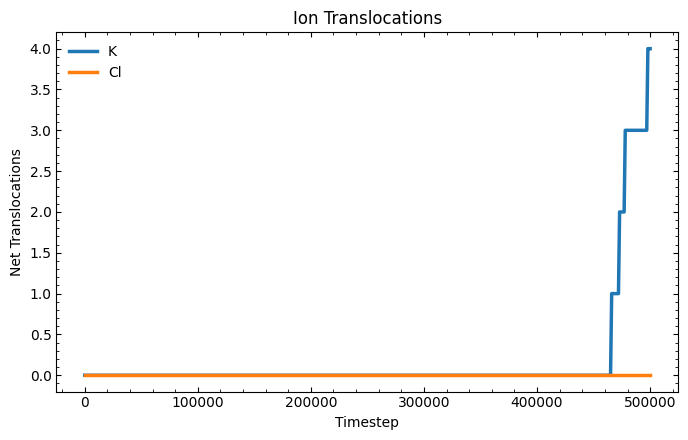

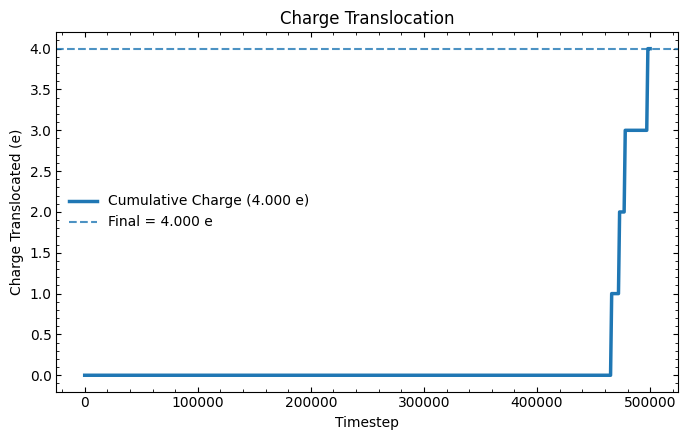

In [6]:
plot_ion_translocations(translocation_I)

plot_charge_translocation(translocation_I)